In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [95]:
df = pd.read_csv('AirQuality_visualization.csv',sep=';')


In [97]:
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [99]:
df.shape

(9471, 17)

In [101]:
df.drop(columns=['Unnamed: 15','Unnamed: 16'],inplace=True)

In [103]:
df.iloc[:,2]= df.iloc[:,2].replace(',','.',regex=True)
df.iloc[:,5]= df.iloc[:,5].replace(',','.',regex=True)
df.iloc[:,12]= df.iloc[:,12].replace(',','.',regex=True)
df.iloc[:,13]= df.iloc[:,13].replace(',','.',regex=True)
df.iloc[:,14]= df.iloc[:,14].replace(',','.',regex=True)

In [105]:
df = df.astype ({'CO(GT)':'float64','C6H6(GT)':'float64','T':'float64','AH':'float64','RH':'float64'})

In [107]:
df.isnull().sum()

Date             114
Time             114
CO(GT)           114
PT08.S1(CO)      114
NMHC(GT)         114
C6H6(GT)         114
PT08.S2(NMHC)    114
NOx(GT)          114
PT08.S3(NOx)     114
NO2(GT)          114
PT08.S4(NO2)     114
PT08.S5(O3)      114
T                114
RH               114
AH               114
dtype: int64

In [109]:
df.dropna(inplace=True)

In [111]:
df.shape

(9357, 15)

In [113]:
df.duplicated().sum()

0

In [115]:
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,04/04/2005,10.00.00,3.1,1314.0,-200.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568
9353,04/04/2005,11.00.00,2.4,1163.0,-200.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
9354,04/04/2005,12.00.00,2.4,1142.0,-200.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406
9355,04/04/2005,13.00.00,2.1,1003.0,-200.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139


In [117]:
df['AH'] = df['AH']*100

In [119]:
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,75.78
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,72.55
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,75.02
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,78.67
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,78.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,04/04/2005,10.00.00,3.1,1314.0,-200.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,75.68
9353,04/04/2005,11.00.00,2.4,1163.0,-200.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,71.19
9354,04/04/2005,12.00.00,2.4,1142.0,-200.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,64.06
9355,04/04/2005,13.00.00,2.1,1003.0,-200.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,51.39


In [121]:
def remove_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    threshold = 1.5 * IQR
    outlier_mask = (column < Q1-threshold)|(column>Q3+threshold)
    return column[~outlier_mask]

In [123]:
col_name = ['T','AH','RH','C6H6(GT)','PT08.S1(CO)','PT08.S2(NMHC)','PT08.S4(NO2)','PT08.S5(O3)']
for col in col_name:
    df[col]= remove_outliers(df[col])

In [125]:
df["Year"] = pd.to_datetime(df['Date'], format = '%d/%m/%Y').dt.year
df["Month"] = pd.to_datetime(df['Date'], format = '%d/%m/%Y').dt.month

In [127]:
df['yeear'] = df.Year.astype(str)
df['month'] = df.Month.astype(str)

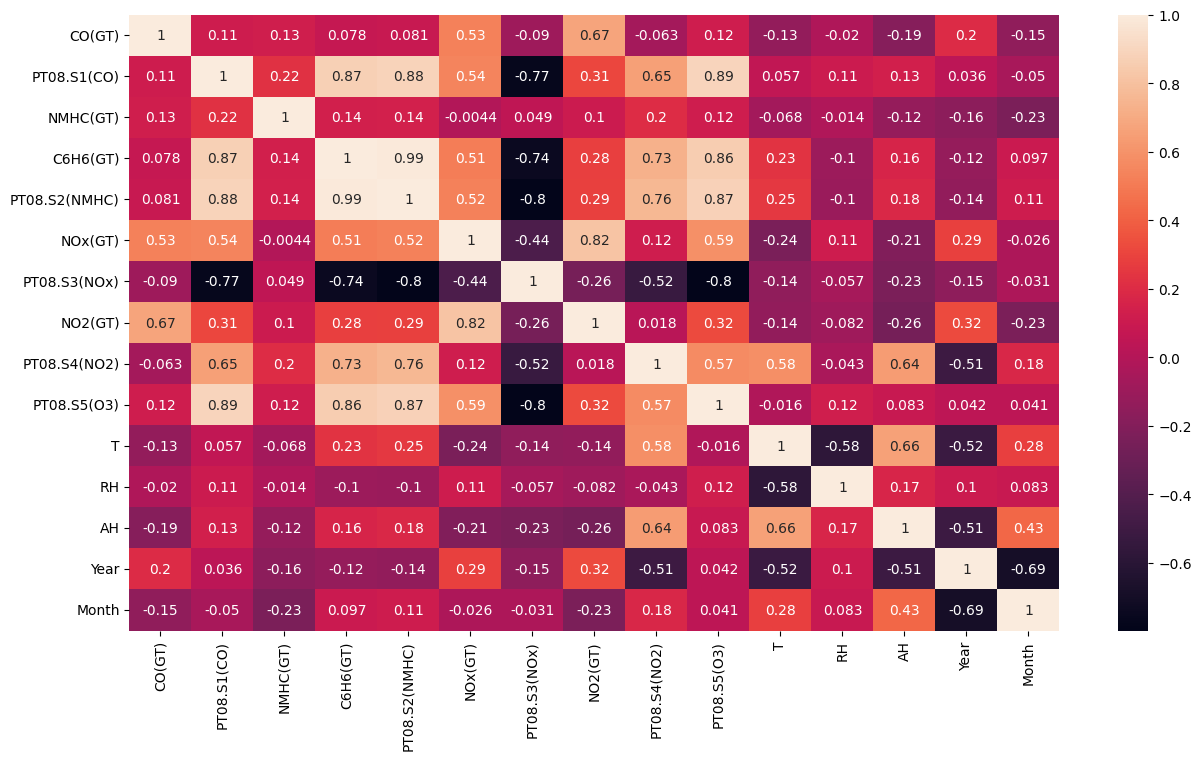

In [129]:
plt.figure(figsize = (15,8))

corr = df.select_dtypes(include = np.number)

sns.heatmap(corr.corr(),annot=True)
plt.show()

<Axes: xlabel='Month', ylabel='AH'>

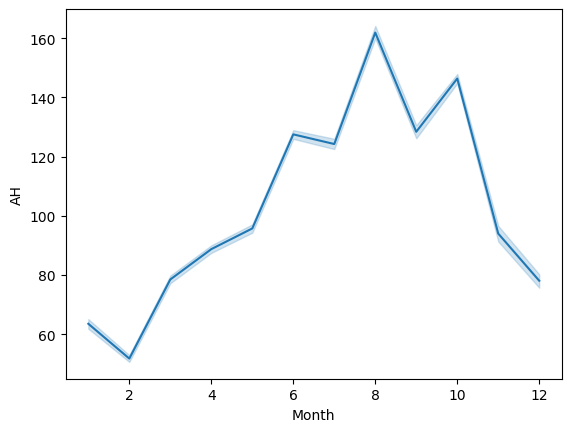

In [130]:
sns.lineplot(df,x='Month',y="AH")

<Axes: xlabel='Year', ylabel='T'>

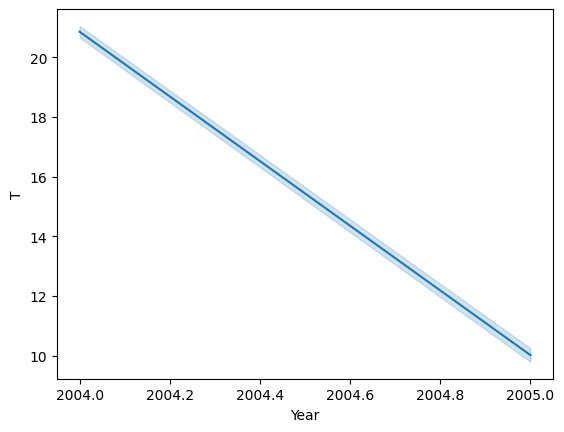

In [131]:
sns.lineplot(df,x='Year',y='T')

<Axes: xlabel='Year', ylabel='T'>

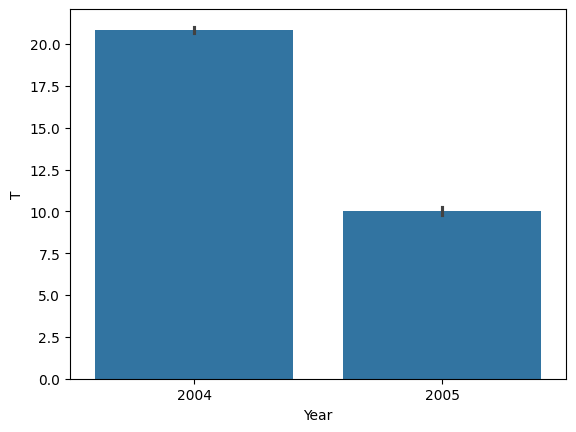

In [132]:
# bar plot

sns.barplot(df,x='Year',y='T')

<Axes: xlabel='PT08.S5(O3)', ylabel='PT08.S1(CO)'>

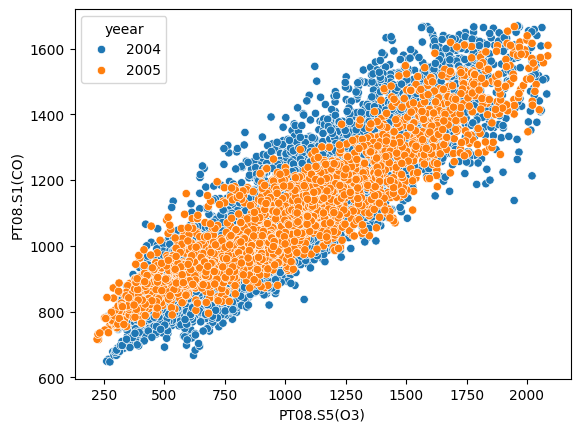

In [140]:
#scatterplot

sns.scatterplot(df,x='PT08.S5(O3)',y='PT08.S1(CO)',hue='yeear')

<Axes: xlabel='T', ylabel='Count'>

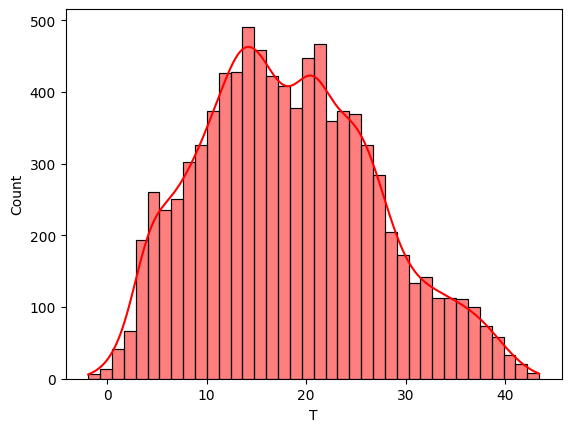

In [148]:
# histogram
sns.histplot(df['T'],kde=True,color='red')

<Axes: xlabel='Month', ylabel='T'>

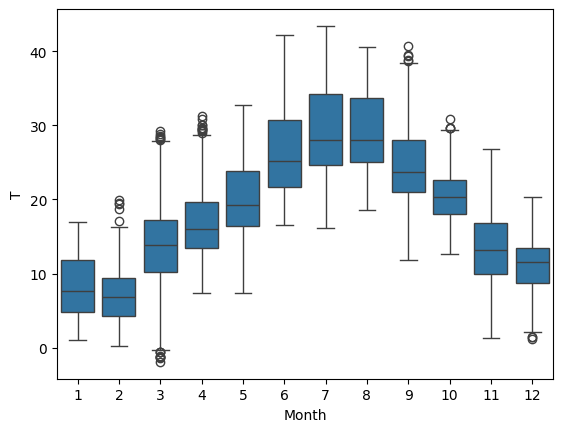

In [152]:
#boxplot
sns.boxplot(df,x='Month',y='T')